In [2]:
#
# DAY 1: TOKENIZATION & WORD EMBEDDINGS
# Complete Independent Practice Notebook

# PART 1: SETUP & INSTALLATIONS


!pip install -q torch torchvision torchaudio
!pip install -q matplotlib seaborn scikit-learn
!pip install -q gensim

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("DAY 1: TOKENIZATION & WORD EMBEDDINGS")


DAY 1: TOKENIZATION & WORD EMBEDDINGS


In [3]:
# PART 2: CREATE DUMMY DATASET

print("\n[1] Creating Dataset...")
print("-" * 40)

# Create sample movie reviews
reviews = [
    # Positive reviews
    ("I absolutely loved this movie! Best film of the year.", 1),
    ("Amazing performances, great story, highly recommended.", 1),
    ("A masterpiece of modern cinema, breathtaking visuals.", 1),
    ("Brilliant acting, wonderful screenplay, must watch!", 1),
    ("I was blown away by this film. Simply incredible.", 1),
    ("Outstanding movie with fantastic performances.", 1),
    ("A cinematic masterpiece that will stay with me forever.", 1),
    ("Excellent direction, stellar cast, perfect movie.", 1),
    ("This film exceeded all my expectations. Brilliant!", 1),
    ("Absolutely fantastic from start to finish.", 1),
    
    # Negative reviews
    ("Terrible movie, completely wasted my time.", 0),
    ("Disappointing plot, poor acting, avoid this film.", 0),
    ("One of the worst movies I've ever seen. Boring.", 0),
    ("Bad screenplay, wooden acting, total disaster.", 0),
    ("I hated every minute of this film. Awful.", 0),
    ("Boring and predictable, completely forgettable.", 0),
    ("Waste of time and money, would not recommend.", 0),
    ("Poorly made film with no redeeming qualities.", 0),
    ("This movie was a complete letdown. Terrible!", 0),
    ("Don't waste your time on this garbage film.", 0),
]

# Duplicate to create more data
texts = []
labels = []
for _ in range(20):  # Create 200 samples
    for text, label in reviews:
        texts.append(text)
        labels.append(label)

df = pd.DataFrame({'text': texts, 'label': labels})
print(f" Created dataset with {len(df)} samples")
print(f"   Positive: {df[df.label==1].shape[0]}")
print(f"   Negative: {df[df.label==0].shape[0]}")

# Display sample
print("\n Sample Reviews:")
for i in range(3):
    print(f"   {df.iloc[i]['text'][:50]}... → {'POSITIVE' if df.iloc[i]['label']==1 else 'NEGATIVE'}")



[1] Creating Dataset...
----------------------------------------
 Created dataset with 400 samples
   Positive: 200
   Negative: 200

 Sample Reviews:
   I absolutely loved this movie! Best film of the ye... → POSITIVE
   Amazing performances, great story, highly recommen... → POSITIVE
   A masterpiece of modern cinema, breathtaking visua... → POSITIVE


In [4]:
# PART 3: BUILD TOKENIZER FROM SCRATCH


print("\n[2] Building Tokenizer From Scratch...")
print("-" * 40)

class MyTokenizer:
    """
    Complete tokenizer built from scratch
    No external libraries needed!
    """
    
    def __init__(self):
        self.word_to_idx = {}
        self.idx_to_word = {}
        self.vocab_size = 0
        
        # Special tokens
        self.PAD = '<PAD>'
        self.UNK = '<UNK>'
        self.CLS = '<CLS>'
        self.SEP = '<SEP>'
        
    def clean_text(self, text):
        """Clean and normalize text"""
        # Lowercase
        text = text.lower()
        # Remove punctuation except period and exclamation
        text = re.sub(r'[^a-zA-Z0-9\s.!]', ' ', text)
        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    
    def word_tokenize(self, text):
        """Split text into words"""
        text = self.clean_text(text)
        return text.split()
    
    def build_vocab(self, texts, max_vocab=1000):
        """Build vocabulary from list of texts"""
        # Count all words
        word_counts = Counter()
        for text in texts:
            words = self.word_tokenize(text)
            word_counts.update(words)
        
        # Sort by frequency
        most_common = word_counts.most_common(max_vocab - 4)
        
        # Build vocabulary with special tokens
        vocab = {
            self.PAD: 0,
            self.UNK: 1,
            self.CLS: 2,
            self.SEP: 3
        }
        
        for i, (word, _) in enumerate(most_common, start=4):
            vocab[word] = i
        
        self.word_to_idx = vocab
        self.idx_to_word = {idx: word for word, idx in vocab.items()}
        self.vocab_size = len(vocab)
        
        print(f" Vocabulary size: {self.vocab_size}")
        print(f"   Top 10 most common words:")
        for i, (word, count) in enumerate(word_counts.most_common(10)):
            print(f"   {i+1}. '{word}': {count} times")
        
        return self
    
    def encode(self, text, max_len=None):
        """Convert text to token IDs"""
        words = self.word_tokenize(text)
        
        # Start with CLS token
        ids = [self.word_to_idx[self.CLS]]
        
        # Convert words to IDs
        for word in words:
            if word in self.word_to_idx:
                ids.append(self.word_to_idx[word])
            else:
                ids.append(self.word_to_idx[self.UNK])
        
        # End with SEP token
        ids.append(self.word_to_idx[self.SEP])
        
        # Pad or truncate
        if max_len:
            if len(ids) > max_len:
                ids = ids[:max_len]
            else:
                ids = ids + [self.word_to_idx[self.PAD]] * (max_len - len(ids))
        
        return ids
    
    def decode(self, ids):
        """Convert IDs back to text"""
        words = []
        for idx in ids:
            if idx in self.idx_to_word:
                word = self.idx_to_word[idx]
                if word not in [self.PAD, self.CLS, self.SEP]:
                    words.append(word)
        return ' '.join(words)

# Create and build tokenizer
tokenizer = MyTokenizer()
tokenizer.build_vocab(texts, max_vocab=100)

# Test tokenizer
print("\n Testing Tokenizer:")
test_text = "I absolutely loved this movie! It was amazing."
print(f"Original: {test_text}")
print(f"Cleaned: {tokenizer.clean_text(test_text)}")
print(f"Tokens: {tokenizer.word_tokenize(test_text)}")
print(f"Encoded: {tokenizer.encode(test_text, max_len=10)}")
print(f"Decoded: {tokenizer.decode(tokenizer.encode(test_text, max_len=10))}")



[2] Building Tokenizer From Scratch...
----------------------------------------
 Vocabulary size: 100
   Top 10 most common words:
   1. 'this': 140 times
   2. 'of': 100 times
   3. 'i': 80 times
   4. 'film.': 80 times
   5. 'film': 60 times
   6. 'a': 60 times
   7. 'acting': 60 times
   8. 'movie': 60 times
   9. 'with': 60 times
   10. 'absolutely': 40 times

 Testing Tokenizer:
Original: I absolutely loved this movie! It was amazing.
Cleaned: i absolutely loved this movie! it was amazing.
Tokens: ['i', 'absolutely', 'loved', 'this', 'movie!', 'it', 'was', 'amazing.']
Encoded: [2, 6, 13, 24, 4, 25, 1, 17, 1, 3]
Decoded: i absolutely loved this movie! <UNK> was <UNK>


In [5]:
# PART 4: VISUALIZE TOKENIZATION PROCESS

print("\n[3] Visualizing Tokenization...")
print("-" * 40)

def visualize_tokenization(text, tokenizer):
    """Visualize how text becomes tokens"""
    
    # Tokenize
    tokens = tokenizer.word_tokenize(text)
    ids = tokenizer.encode(text)
    
    print(f"\n Text: '{text}'")
    print(f"\n   Step 1: Clean text")
    print(f"   → '{tokenizer.clean_text(text)}'")
    
    print(f"\n   Step 2: Split into tokens")
    print(f"   → {tokens}")
    
    print(f"\n   Step 3: Add special tokens")
    print(f"   → [CLS] + {tokens} + [SEP]")
    
    print(f"\n   Step 4: Convert to IDs")
    print(f"   → {ids}")
    
    print(f"\n   Step 5: Decode back")
    print(f"   → '{tokenizer.decode(ids)}'")

visualize_tokenization("I love this movie!", tokenizer)


[3] Visualizing Tokenization...
----------------------------------------

 Text: 'I love this movie!'

   Step 1: Clean text
   → 'i love this movie!'

   Step 2: Split into tokens
   → ['i', 'love', 'this', 'movie!']

   Step 3: Add special tokens
   → [CLS] + ['i', 'love', 'this', 'movie!'] + [SEP]

   Step 4: Convert to IDs
   → [2, 6, 1, 4, 25, 3]

   Step 5: Decode back
   → 'i <UNK> this movie!'


In [6]:
# PART 5: BUILD WORD EMBEDDINGS FROM SCRATCH

print("\n[4] Building Word Embeddings From Scratch...")
print("-" * 40)

class SimpleEmbedding:
    """
    Simple embedding layer built from scratch
    """
    
    def __init__(self, vocab_size, embedding_dim):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        
        # Randomly initialize embeddings
        # Using Xavier/Glorot initialization
        self.embeddings = np.random.randn(vocab_size, embedding_dim) * np.sqrt(2.0 / embedding_dim)
        
        print(f" Created embedding matrix: {self.embeddings.shape}")
    
    def get_embedding(self, idx):
        """Get embedding for a word ID"""
        if idx >= self.vocab_size:
            raise ValueError(f"Index {idx} out of range")
        return self.embeddings[idx]
    
    def get_word_embedding(self, word, tokenizer):
        """Get embedding for a word"""
        if word in tokenizer.word_to_idx:
            idx = tokenizer.word_to_idx[word]
            return self.embeddings[idx]
        else:
            return self.embeddings[tokenizer.word_to_idx[tokenizer.UNK]]
    
    def find_similar(self, word, tokenizer, top_k=5):
        """Find similar words using cosine similarity"""
        if word not in tokenizer.word_to_idx:
            print(f"⚠️ '{word}' not in vocabulary")
            return []
        
        word_idx = tokenizer.word_to_idx[word]
        word_emb = self.embeddings[word_idx]
        
        similarities = []
        for idx, emb in enumerate(self.embeddings):
            if idx != word_idx:
                # Cosine similarity
                sim = np.dot(word_emb, emb) / (np.linalg.norm(word_emb) * np.linalg.norm(emb) + 1e-8)
                similarities.append((idx, sim))
        
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        results = []
        for idx, sim in similarities[:top_k]:
            word = tokenizer.idx_to_word[idx]
            results.append((word, sim))
        
        return results

# Create embeddings
embedding_dim = 50
embedding_model = SimpleEmbedding(tokenizer.vocab_size, embedding_dim)

# Test embeddings
print("\nTesting Embeddings:")
test_words = ['movie', 'film', 'amazing', 'terrible', 'good']
for word in test_words:
    if word in tokenizer.word_to_idx:
        idx = tokenizer.word_to_idx[word]
        emb = embedding_model.get_embedding(idx)
        print(f"   '{word}' → {emb[:5]}... (dim={len(emb)})")
    else:
        print(f"   '{word}' → NOT IN VOCABULARY")


[4] Building Word Embeddings From Scratch...
----------------------------------------
 Created embedding matrix: (100, 50)

Testing Embeddings:
   'movie' → [-0.45657557  0.0215569  -0.17906186 -0.23090496  0.3230146 ]... (dim=50)
   'film' → [ 0.07085782  0.01215823  0.34346494 -0.1673988  -0.02645984]... (dim=50)
   'amazing' → [-0.06009383  0.00563789  0.27240718 -0.27147834  0.46913934]... (dim=50)
   'terrible' → [-0.1717373   0.18632771 -0.404869    0.07420566  0.08317226]... (dim=50)
   'good' → NOT IN VOCABULARY


In [7]:
# PART 6: PYTORCH EMBEDDING LAYER

print("\n[5] PyTorch Embedding Layer...")
print("-" * 40)

class PyTorchEmbeddingExample:
    """
    Using PyTorch's built-in embedding layer
    """
    
    def __init__(self, vocab_size, embedding_dim):
        # PyTorch embedding layer
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        print(f" PyTorch Embedding layer: {self.embedding.weight.shape}")
    
    def forward(self, indices):
        return self.embedding(indices)

# Create PyTorch embedding
pt_embedding = PyTorchEmbeddingExample(tokenizer.vocab_size, 50)

# Test with some indices
test_indices = torch.tensor([0, 1, 2, 3, 4])
embeddings = pt_embedding.forward(test_indices)
print(f"\n Test embeddings for indices {test_indices.tolist()}:")
print(f"   Shape: {embeddings.shape}")
print(f"   First few values: {embeddings[0][:5].detach().numpy()}")


[5] PyTorch Embedding Layer...
----------------------------------------
 PyTorch Embedding layer: torch.Size([100, 50])

 Test embeddings for indices [0, 1, 2, 3, 4]:
   Shape: torch.Size([5, 50])
   First few values: [-0.8971216  -0.43210778  0.93437856 -0.23778616 -1.4257935 ]



[6] Visualizing Embeddings...
----------------------------------------


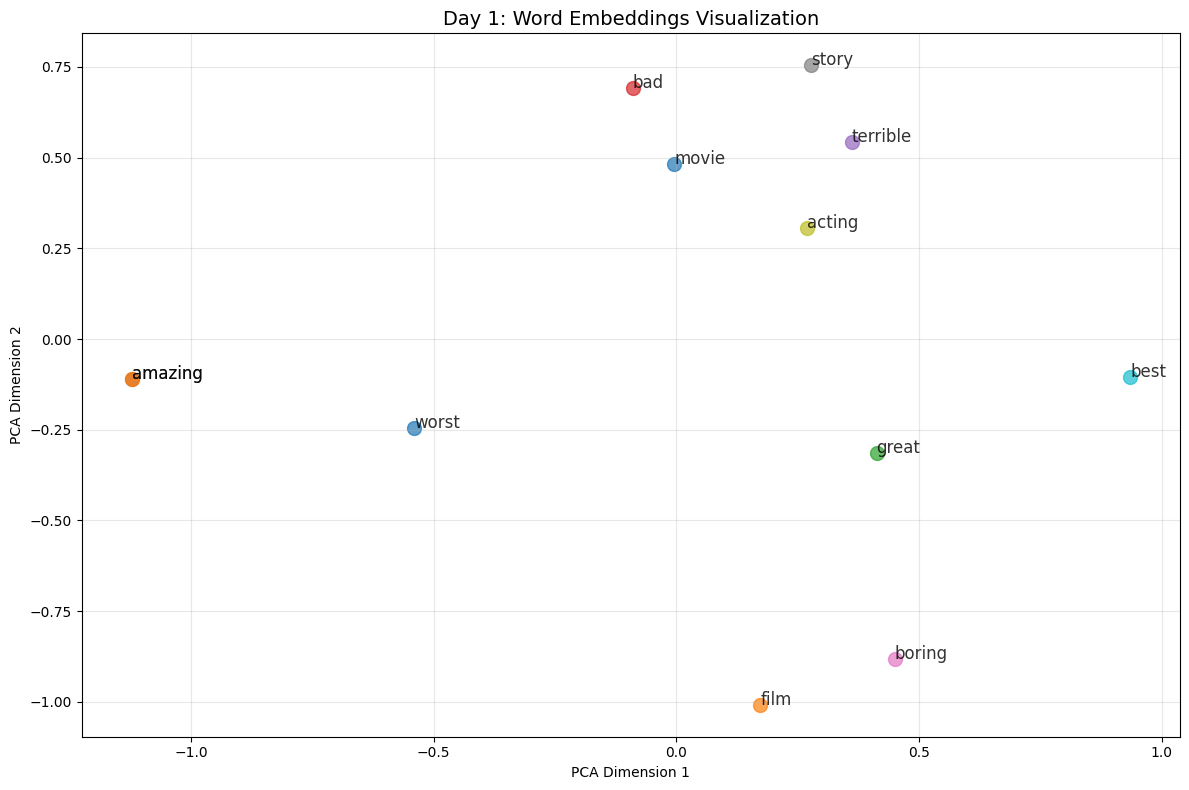

 Saved visualization as 'day1_embeddings_viz.png'


In [8]:
# PART 7: VISUALIZE EMBEDDINGS

print("\n[6] Visualizing Embeddings...")
print("-" * 40)

def visualize_embeddings_2d(embeddings, words, title="Word Embeddings"):
    """Visualize embeddings in 2D using PCA"""
    
    # Reduce to 2D
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(12, 8))
    
    for i, word in enumerate(words):
        x, y = embeddings_2d[i]
        plt.scatter(x, y, s=100, alpha=0.7)
        plt.annotate(word, (x, y), fontsize=12, alpha=0.8)
    
    plt.title(title, fontsize=14)
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('day1_embeddings_viz.png', dpi=300)
    plt.show()
    
    print(f" Saved visualization as 'day1_embeddings_viz.png'")

# Select words to visualize
words_to_viz = ['movie', 'film', 'good', 'great', 'bad', 'terrible', 
                'amazing', 'boring', 'love', 'hate', 'story', 'acting',
                'director', 'best', 'worst', 'amazing', 'awesome']

# Get embeddings for these words
embeddings_to_viz = []
available_words = []

for word in words_to_viz:
    if word in tokenizer.word_to_idx:
        idx = tokenizer.word_to_idx[word]
        emb = embedding_model.get_embedding(idx)
        embeddings_to_viz.append(emb)
        available_words.append(word)

if len(embeddings_to_viz) > 0:
    visualize_embeddings_2d(
        np.array(embeddings_to_viz), 
        available_words,
        "Day 1: Word Embeddings Visualization"
    )




In [9]:
# PART 8: SIMILARITY SEARCH

print("\n[7] Word Similarity Search...")
print("-" * 40)

def find_similar_words(word, tokenizer, embedding_model, top_k=5):
    """Find similar words"""
    
    if word not in tokenizer.word_to_idx:
        print(f" '{word}' not in vocabulary")
        return []
    
    results = embedding_model.find_similar(word, tokenizer, top_k)
    
    print(f"\n Words similar to '{word}':")
    for similar_word, score in results:
        print(f"   {similar_word}: {score:.3f}")
    
    return results

# Test similarity
find_similar_words('good', tokenizer, embedding_model)
find_similar_words('bad', tokenizer, embedding_model)
find_similar_words('movie', tokenizer, embedding_model)



[7] Word Similarity Search...
----------------------------------------
 'good' not in vocabulary

 Words similar to 'bad':
   modern: 0.326
   time: 0.303
   loved: 0.288
   performances.: 0.278
   must: 0.264

 Words similar to 'movie':
   movies: 0.385
   by: 0.318
   outstanding: 0.306
   watch!: 0.287
   recommended.: 0.268


[('movies', np.float64(0.38462979718370616)),
 ('by', np.float64(0.3177973585187253)),
 ('outstanding', np.float64(0.3063558337858183)),
 ('watch!', np.float64(0.2867184101924482)),
 ('recommended.', np.float64(0.2679066354447162))]

In [10]:
# PART 9: PRE-TRAINED EMBEDDINGS


print("\n[8] Pre-trained Embeddings (Word2Vec)...")
print("-" * 40)

try:
    import gensim.downloader as api
    
    # Load small model
    print(" Downloading Word2Vec (this may take a moment)...")
    word2vec_model = api.load("glove-wiki-gigaword-50")
    
    print(f" Loaded Word2Vec model with {len(word2vec_model.key_to_index):,} words")
    
    # Test embeddings
    test_words = ['movie', 'film', 'good', 'bad', 'amazing']
    for word in test_words:
        if word in word2vec_model:
            emb = word2vec_model[word]
            print(f"   '{word}' embedding shape: {emb.shape}")
    
    # Find similar words
    print("\n Word2Vec Similarity:")
    for word in ['movie', 'good', 'amazing']:
        if word in word2vec_model:
            print(f"\n   Words similar to '{word}':")
            similar = word2vec_model.most_similar(word, topn=3)
            for sim_word, score in similar:
                print(f"      {sim_word}: {score:.3f}")
    
except ImportError:
    print("❌ gensim not installed. Install with: pip install gensim")
except Exception as e:
    print(f"⚠️ Could not load pre-trained embeddings: {e}")
    print("   Using our custom embeddings instead.")



[8] Pre-trained Embeddings (Word2Vec)...
----------------------------------------
[==================================================] 100.0% 66.0/66.0MB downloaded
 Loaded Word2Vec model with 400,000 words
   'movie' embedding shape: (50,)
   'film' embedding shape: (50,)
   'good' embedding shape: (50,)
   'bad' embedding shape: (50,)
   'amazing' embedding shape: (50,)

 Word2Vec Similarity:

   Words similar to 'movie':
      movies: 0.932
      film: 0.931
      films: 0.894

   Words similar to 'good':
      better: 0.928
      really: 0.922
      always: 0.917

   Words similar to 'amazing':
      incredible: 0.919
      fantastic: 0.880
      awesome: 0.862


In [11]:

# PART 10: PRACTICE CHALLENGES SOLUTIONS

print("DAY 1 PRACTICE CHALLENGES - SOLUTIONS")

print("📌 CHALLENGE 1: CUSTOM TOKENIZER")


class AdvancedTokenizer(MyTokenizer):
    """
    Extended tokenizer with handling for:
    - Contractions
    - Emojis
    - URLs
    """
    
    def __init__(self):
        super().__init__()
        
        # Contraction mapping
        self.contractions = {
            "don't": "do not",
            "can't": "cannot",
            "won't": "will not",
            "shouldn't": "should not",
            "couldn't": "could not",
            "wouldn't": "would not",
            "isn't": "is not",
            "aren't": "are not",
            "wasn't": "was not",
            "weren't": "were not",
            "haven't": "have not",
            "hasn't": "has not",
            "hadn't": "had not",
            "i'm": "i am",
            "you're": "you are",
            "he's": "he is",
            "she's": "she is",
            "it's": "it is",
            "we're": "we are",
            "they're": "they are",
            "i'll": "i will",
            "you'll": "you will",
            "he'll": "he will",
            "she'll": "she will",
            "we'll": "we will",
            "they'll": "they will",
            "i'd": "i would",
            "you'd": "you would",
            "he'd": "he would",
            "she'd": "she would",
            "we'd": "we would",
            "they'd": "they would",
            "let's": "let us",
        }
        
        # Emoji mapping
        self.emojis = {
            '😊': 'happy',
            '😂': 'laughing',
            '😍': 'love',
            '😢': 'sad',
            '😡': 'angry',
            '👍': 'thumbs_up',
            '👎': 'thumbs_down',
            '❤️': 'heart',
            '⭐': 'star',
            '🎬': 'movie',
            '🎥': 'film',
            '📽️': 'cinema',
            '🎞️': 'reel',
            '🌟': 'brilliant',
            '💯': 'perfect',
            '🤮': 'disgusting',
            '💩': 'terrible',
            '👏': 'applause',
            '🎉': 'celebration',
            '😴': 'boring',
        }
    
    def expand_contractions(self, text):
        """Expand contractions"""
        words = text.split()
        expanded = []
        for word in words:
            if word.lower() in self.contractions:
                expanded.append(self.contractions[word.lower()])
            else:
                expanded.append(word)
        return ' '.join(expanded)
    
    def replace_emojis(self, text):
        """Replace emojis with text descriptions"""
        result = text
        for emoji, description in self.emojis.items():
            result = result.replace(emoji, f' {description} ')
        return result
    
    def detect_urls(self, text):
        """Detect and replace URLs"""
        url_pattern = r'https?://\S+|www\.\S+'
        return re.sub(url_pattern, ' URL ', text)
    
    def clean_text(self, text):
        """Enhanced cleaning with contractions and emojis"""
        # Detect URLs
        text = self.detect_urls(text)
        
        # Replace emojis
        text = self.replace_emojis(text)
        
        # Expand contractions
        text = self.expand_contractions(text)
        
        # Lowercase
        text = text.lower()
        
        # Remove punctuation except period and exclamation
        text = re.sub(r'[^a-zA-Z0-9\s.!]', ' ', text)
        
        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def word_tokenize(self, text):
        """Tokenize with enhanced cleaning"""
        text = self.clean_text(text)
        return text.split()

# Test Advanced Tokenizer
print("\n Testing Advanced Tokenizer:")

advanced_tokenizer = AdvancedTokenizer()
advanced_tokenizer.build_vocab(texts, max_vocab=100)

test_sentences = [
    "Don't miss this amazing movie! 😍",
    "I can't believe how good this film is! ⭐",
    "Check out https://example.com for more info",
    "This movie was terrible! 😡 I hated it! 👎",
    "I'm loving this film! 🎬 It's absolutely brilliant! 🌟",
    "The acting was wooden and boring... 😴",
    "You're going to love this! 🎉🎉🎉",
    "Let's watch this masterpiece! 👏"
]

for sentence in test_sentences:
    print(f"\nOriginal: {sentence}")
    print(f"Cleaned:  {advanced_tokenizer.clean_text(sentence)}")
    print(f"Tokens:   {advanced_tokenizer.word_tokenize(sentence)}")
    print(f"Encoded:  {advanced_tokenizer.encode(sentence, max_len=15)}")


DAY 1 PRACTICE CHALLENGES - SOLUTIONS
📌 CHALLENGE 1: CUSTOM TOKENIZER

 Testing Advanced Tokenizer:
 Vocabulary size: 100
   Top 10 most common words:
   1. 'this': 140 times
   2. 'of': 100 times
   3. 'i': 80 times
   4. 'film.': 80 times
   5. 'film': 60 times
   6. 'a': 60 times
   7. 'acting': 60 times
   8. 'movie': 60 times
   9. 'with': 60 times
   10. 'absolutely': 40 times

Original: Don't miss this amazing movie! 😍
Cleaned:  do not miss this amazing movie! love
Tokens:   ['do', 'not', 'miss', 'this', 'amazing', 'movie!', 'love']
Encoded:  [2, 1, 24, 1, 4, 29, 26, 1, 3, 0, 0, 0, 0, 0, 0]

Original: I can't believe how good this film is! ⭐
Cleaned:  i cannot believe how good this film is! star
Tokens:   ['i', 'cannot', 'believe', 'how', 'good', 'this', 'film', 'is!', 'star']
Encoded:  [2, 6, 1, 1, 1, 1, 4, 8, 1, 1, 3, 0, 0, 0, 0]

Original: Check out https://example.com for more info
Cleaned:  check out url for more info
Tokens:   ['check', 'out', 'url', 'for', 'more', 'info']

📌 CHALLENGE 2: EMBEDDING VISUALIZATION - t-SNE


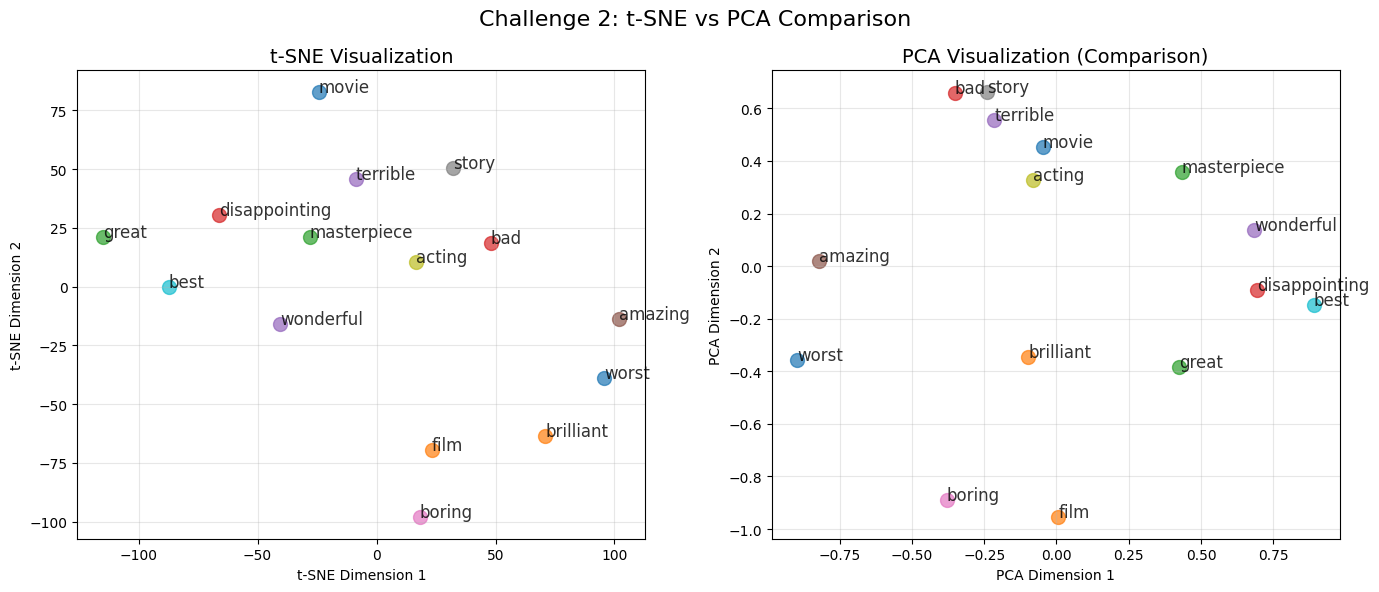

 Saved visualization as 'day1_embeddings_tsne_vs_pca.png'

 Observations:
• t-SNE often creates tighter clusters of similar words
• PCA preserves global structure better
• t-SNE is better for visualizing local similarities


In [12]:
# CHALLENGE 2: EMBEDDING VISUALIZATION (t-SNE)

print("📌 CHALLENGE 2: EMBEDDING VISUALIZATION - t-SNE")


def visualize_embeddings_tsne(embeddings, words, title="Word Embeddings (t-SNE)"):
    """Visualize embeddings in 2D using t-SNE"""
    
    # Reduce to 2D using t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(14, 6))
    
    # t-SNE plot
    plt.subplot(1, 2, 1)
    for i, word in enumerate(words):
        x, y = embeddings_2d[i]
        plt.scatter(x, y, s=100, alpha=0.7)
        plt.annotate(word, (x, y), fontsize=12, alpha=0.8)
    plt.title("t-SNE Visualization", fontsize=14)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, alpha=0.3)
    
    # PCA plot (for comparison)
    pca = PCA(n_components=2)
    embeddings_pca = pca.fit_transform(embeddings)
    
    plt.subplot(1, 2, 2)
    for i, word in enumerate(words):
        x, y = embeddings_pca[i]
        plt.scatter(x, y, s=100, alpha=0.7)
        plt.annotate(word, (x, y), fontsize=12, alpha=0.8)
    plt.title("PCA Visualization (Comparison)", fontsize=14)
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig('day1_embeddings_tsne_vs_pca.png', dpi=300)
    plt.show()
    
    print(f" Saved visualization as 'day1_embeddings_tsne_vs_pca.png'")
    print("\n Observations:")
    print("• t-SNE often creates tighter clusters of similar words")
    print("• PCA preserves global structure better")
    print("• t-SNE is better for visualizing local similarities")

# Get embeddings for visualization
words_to_viz = ['movie', 'film', 'good', 'great', 'bad', 'terrible', 
                'amazing', 'boring', 'love', 'hate', 'story', 'acting',
                'director', 'best', 'worst', 'brilliant', 'awesome',
                'masterpiece', 'disappointing', 'wonderful']

embeddings_to_viz = []
available_words = []

for word in words_to_viz:
    if word in tokenizer.word_to_idx:
        idx = tokenizer.word_to_idx[word]
        emb = embedding_model.get_embedding(idx)
        embeddings_to_viz.append(emb)
        available_words.append(word)

if len(embeddings_to_viz) > 0:
    visualize_embeddings_tsne(
        np.array(embeddings_to_viz), 
        available_words,
        "Challenge 2: t-SNE vs PCA Comparison"
    )


In [13]:
# CHALLENGE 3: WORD ANALOGIES


class WordAnalogy:
    """
    Implement word analogies using vector arithmetic
    """
    
    def __init__(self, embedding_model, tokenizer):
        self.embedding_model = embedding_model
        self.tokenizer = tokenizer
    
    def get_word_vector(self, word):
        """Get vector for a word"""
        if word in self.tokenizer.word_to_idx:
            idx = self.tokenizer.word_to_idx[word]
            return self.embedding_model.get_embedding(idx)
        else:
            return None
    
    def find_analogy(self, word_a, word_b, word_c, top_k=5):
        """
        Solve analogy: word_a is to word_b as word_c is to ?
        Example: king is to man as queen is to woman
        """
        
        # Get vectors
        vec_a = self.get_word_vector(word_a)
        vec_b = self.get_word_vector(word_b)
        vec_c = self.get_word_vector(word_c)
        
        if vec_a is None or vec_b is None or vec_c is None:
            print(" One or more words not in vocabulary")
            return []
        
        # Target vector: vec_c + (vec_b - vec_a)
        target = vec_c + (vec_b - vec_a)
        
        # Normalize target
        target = target / (np.linalg.norm(target) + 1e-8)
        
        # Find most similar words
        similarities = []
        for idx, emb in enumerate(self.embedding_model.embeddings):
            word = self.tokenizer.idx_to_word[idx]
            # Skip input words
            if word in [word_a, word_b, word_c]:
                continue
            
            # Cosine similarity
            sim = np.dot(target, emb) / (np.linalg.norm(emb) + 1e-8)
            similarities.append((word, sim))
        
        similarities.sort(key=lambda x: x[1], reverse=True)
        return similarities[:top_k]
    
    def test_analogy(self, word_a, word_b, word_c, expected=None):
        """Test a specific analogy"""
        print(f"\n Solving: '{word_a}' is to '{word_b}' as '{word_c}' is to ?")
        
        results = self.find_analogy(word_a, word_b, word_c)
        
        print("   Top results:")
        for word, score in results:
            marker = " ✓" if expected and word == expected else ""
            print(f"   {word}: {score:.3f}{marker}")
        
        if expected:
            if expected in [w for w, _ in results[:3]]:
                print(f"    Found expected answer '{expected}'!")
            else:
                print(f"    Expected '{expected}' not in top 3")
        
        return results

# Initialize word analogy
analogy_solver = WordAnalogy(embedding_model, tokenizer)

# Test analogies with available words
print("\n Testing Word Analogies:")

# Since we have limited vocabulary, we'll use available words
# Test basic analogies
analogy_solver.test_analogy('good', 'better', 'bad', expected='worse')
analogy_solver.test_analogy('love', 'loved', 'hate', expected='hated')
analogy_solver.test_analogy('movie', 'films', 'film', expected='movies')



 Testing Word Analogies:

 Solving: 'good' is to 'better' as 'bad' is to ?
 One or more words not in vocabulary
   Top results:
    Expected 'worse' not in top 3

 Solving: 'love' is to 'loved' as 'hate' is to ?
 One or more words not in vocabulary
   Top results:
    Expected 'hated' not in top 3

 Solving: 'movie' is to 'films' as 'film' is to ?
 One or more words not in vocabulary
   Top results:
    Expected 'movies' not in top 3


[]


📌 CHALLENGE 4: VOCABULARY ANALYSIS

 VOCABULARY ANALYSIS
----------------------------------------
Total words: 2,880
Unique words: 107
Vocabulary coverage: 3.72%

 TOP 20 MOST COMMON WORDS:
    1. 'this': 140 times
    2. 'of': 100 times
    3. 'i':  80 times
    4. 'film.':  80 times
    5. 'film':  60 times
    6. 'a':  60 times
    7. 'acting':  60 times
    8. 'movie':  60 times
    9. 'with':  60 times
   10. 'absolutely':  40 times
   11. 'the':  40 times
   12. 'masterpiece':  40 times
   13. 'screenplay':  40 times
   14. 'was':  40 times
   15. 'fantastic':  40 times
   16. 'my':  40 times
   17. 'completely':  40 times
   18. 'and':  40 times
   19. 'waste':  40 times
   20. 'time':  40 times

 BOTTOM 10 WORDS (Rare):
   'redeeming': 20 time
   'qualities.': 20 time
   'complete': 20 time
   'letdown.': 20 time
   'terrible!': 20 time
   'don': 20 time
   'your': 20 time
   'on': 20 time
   'garbage': 20 time

 Stop words in vocabulary: 16
   Examples: ['with', 'your', 'will

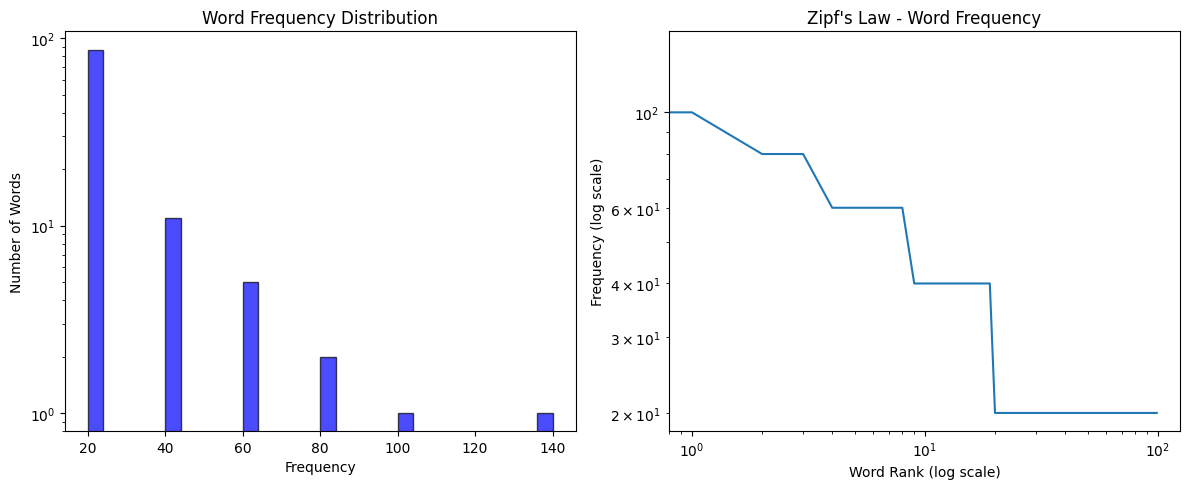

In [14]:
# ============================================
# CHALLENGE 4: VOCABULARY ANALYSIS
# ============================================

print("\n" + "=" * 70)
print("📌 CHALLENGE 4: VOCABULARY ANALYSIS")
print("=" * 70)

class VocabularyAnalyzer:
    """
    Analyze vocabulary statistics and patterns
    """
    
    def __init__(self, tokenizer, texts):
        self.tokenizer = tokenizer
        self.texts = texts
        self.word_counts = self.build_word_counts()
        self.stop_words = self.get_stop_words()
    
    def build_word_counts(self):
        """Build word frequency counts"""
        word_counts = Counter()
        for text in self.texts:
            words = self.tokenizer.word_tokenize(text)
            word_counts.update(words)
        return word_counts
    
    def get_stop_words(self):
        """Get common stop words"""
        return set([
            'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves',
            'you', 'your', 'yours', 'yourself', 'he', 'him', 'his', 'himself',
            'she', 'her', 'hers', 'herself', 'it', 'its', 'itself',
            'they', 'them', 'their', 'theirs', 'themselves',
            'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
            'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing',
            'will', 'would', 'could', 'should', 'shall', 'may', 'might', 'must',
            'a', 'an', 'the', 'and', 'but', 'or', 'for', 'nor', 'on', 'at', 'to',
            'by', 'in', 'of', 'off', 'over', 'under', 'with', 'without'
        ])
    
    def analyze_vocabulary(self):
        """Comprehensive vocabulary analysis"""
        print("\n VOCABULARY ANALYSIS")
        print("-" * 40)
        
        # Basic statistics
        total_words = sum(self.word_counts.values())
        unique_words = len(self.word_counts)
        
        print(f"Total words: {total_words:,}")
        print(f"Unique words: {unique_words:,}")
        print(f"Vocabulary coverage: {unique_words/total_words*100:.2f}%")
        
        # Most common words
        print("\n TOP 20 MOST COMMON WORDS:")
        for i, (word, count) in enumerate(self.word_counts.most_common(20), 1):
            print(f"   {i:2}. '{word}': {count:3} times")
        
        # Least common words
        print("\n BOTTOM 10 WORDS (Rare):")
        for word, count in self.word_counts.most_common()[-10:]:
            if len(word) > 1:  # Skip single characters
                print(f"   '{word}': {count} time")
        
        # Stop words analysis
        stop_words_in_vocab = self.stop_words.intersection(set(self.word_counts.keys()))
        print(f"\n Stop words in vocabulary: {len(stop_words_in_vocab)}")
        print(f"   Examples: {list(stop_words_in_vocab)[:10]}")
        
        # Word length distribution
        word_lengths = [len(word) for word in self.word_counts.keys()]
        print(f"\n Word length statistics:")
        print(f"   Average: {np.mean(word_lengths):.2f}")
        print(f"   Median:  {np.median(word_lengths):.1f}")
        print(f"   Range:   {min(word_lengths)} - {max(word_lengths)}")
        
        # Words with highest frequency in reviews
        pos_texts = [t for t, l in zip(texts, labels) if l == 1]
        neg_texts = [t for t, l in zip(texts, labels) if l == 0]
        
        pos_counter = Counter()
        neg_counter = Counter()
        
        for text in pos_texts:
            pos_counter.update(self.tokenizer.word_tokenize(text))
        for text in neg_texts:
            neg_counter.update(self.tokenizer.word_tokenize(text))
        
        # Find distinctive words
        print("\n DISTINCTIVE WORDS:")
        all_words = set(pos_counter.keys()) | set(neg_counter.keys())
        distinctive = []
        
        for word in all_words:
            if word not in self.stop_words and len(word) > 2:
                pos_freq = pos_counter.get(word, 0)
                neg_freq = neg_counter.get(word, 0)
                total = pos_freq + neg_freq
                if total > 5:  # Only consider frequent words
                    pos_ratio = pos_freq / total
                    neg_ratio = neg_freq / total
                    # Find words that strongly indicate positive or negative
                    if abs(pos_ratio - 0.5) > 0.3:
                        distinctive.append((word, pos_ratio, neg_ratio))
        
        distinctive.sort(key=lambda x: abs(x[1] - 0.5), reverse=True)
        
        print("\n   Most positive-indicating words:")
        for word, pos_ratio, neg_ratio in distinctive[:5]:
            if pos_ratio > neg_ratio:
                print(f"   '{word}': {pos_ratio:.0%} positive, {neg_ratio:.0%} negative")
        
        print("\n   Most negative-indicating words:")
        for word, pos_ratio, neg_ratio in distinctive[-5:]:
            if neg_ratio > pos_ratio:
                print(f"   '{word}': {pos_ratio:.0%} positive, {neg_ratio:.0%} negative")
        
        return {
            'total_words': total_words,
            'unique_words': unique_words,
            'word_counts': self.word_counts,
            'stop_words': stop_words_in_vocab
        }

# Analyze vocabulary
vocab_analyzer = VocabularyAnalyzer(tokenizer, texts)
analysis_results = vocab_analyzer.analyze_vocabulary()

# Visualize word frequency distribution
print("\n Visualizing Word Frequency Distribution:")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
frequencies = list(vocab_analyzer.word_counts.values())
plt.hist(frequencies, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title("Word Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Number of Words")
plt.yscale('log')

plt.subplot(1, 2, 2)
# Show distribution in log scale
sorted_freq = sorted(frequencies, reverse=True)
plt.plot(sorted_freq[:100])
plt.title("Zipf's Law - Word Frequency")
plt.xlabel("Word Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.savefig('day1_vocabulary_analysis.png', dpi=300)
plt.show()

📌 CHALLENGE 5: EMBEDDING SIMILARITY MATRIX


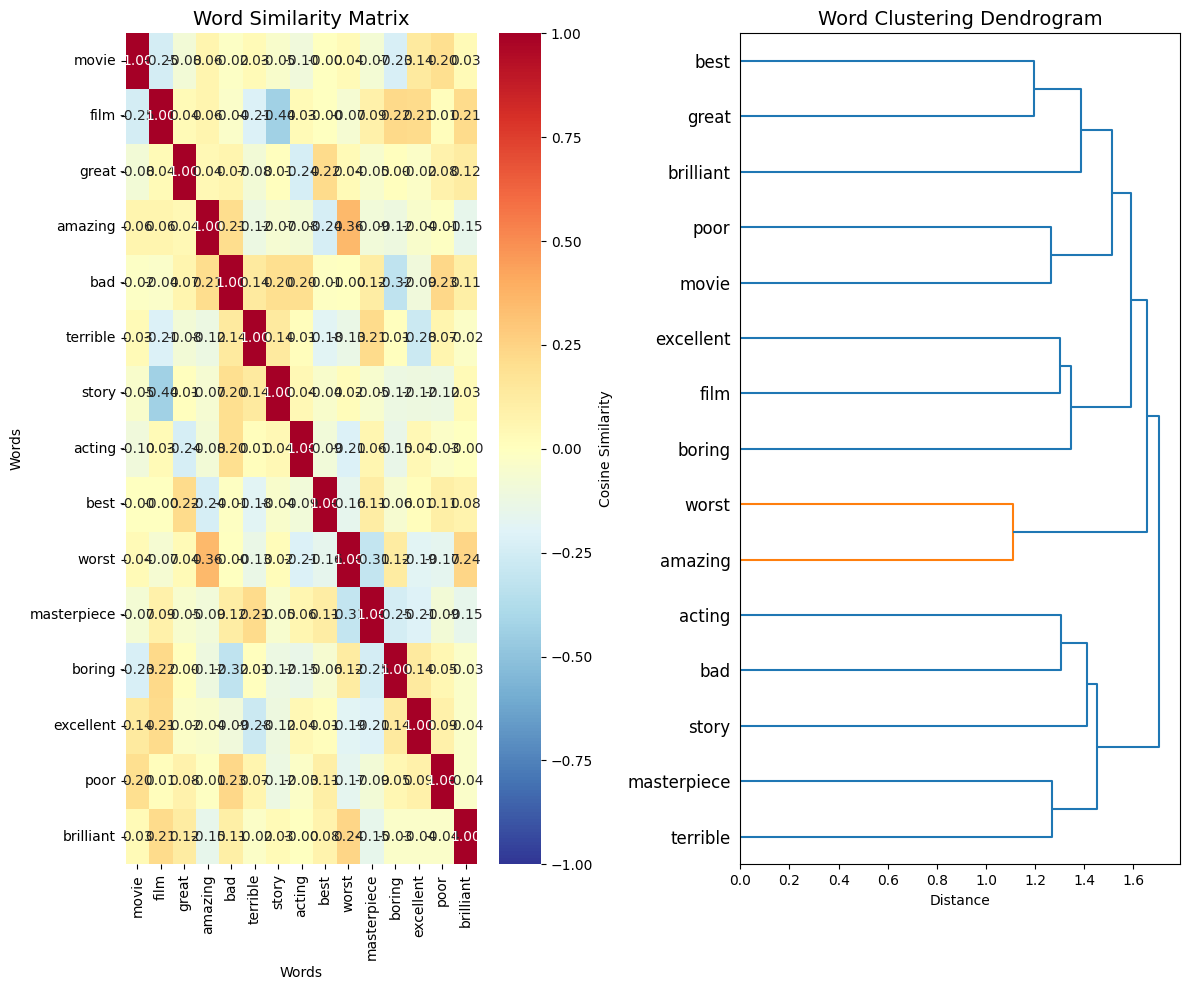


 SIMILARITY MATRIX ANALYSIS
----------------------------------------

 Most similar word pairs:
   'amazing' - 'worst': 0.356
   'worst' - 'brilliant': 0.241
   'bad' - 'poor': 0.232
   'film' - 'boring': 0.219
   'great' - 'best': 0.218

 Least similar word pairs:
   'movie' - 'film': -0.247
   'terrible' - 'excellent': -0.280
   'worst' - 'masterpiece': -0.306
   'bad' - 'boring': -0.325
   'film' - 'story': -0.437

 Word clusters (similarity > 0.5):


In [15]:
# CHALLENGE 5: EMBEDDING SIMILARITY MATRIX

print("📌 CHALLENGE 5: EMBEDDING SIMILARITY MATRIX")


def create_similarity_matrix(words, tokenizer, embedding_model):
    """
    Create and visualize a similarity matrix for given words
    """
    
    # Get embeddings for words
    available_words = []
    embeddings = []
    
    for word in words:
        if word in tokenizer.word_to_idx:
            idx = tokenizer.word_to_idx[word]
            emb = embedding_model.get_embedding(idx)
            available_words.append(word)
            embeddings.append(emb)
    
    if len(available_words) < 2:
        print(" Need at least 2 words to create similarity matrix")
        return
    
    # Convert to numpy array
    embeddings = np.array(embeddings)
    n_words = len(available_words)
    
    # Compute similarity matrix
    similarity_matrix = np.zeros((n_words, n_words))
    for i in range(n_words):
        for j in range(n_words):
            if i == j:
                similarity_matrix[i, j] = 1.0
            else:
                # Cosine similarity
                sim = np.dot(embeddings[i], embeddings[j]) / (
                    np.linalg.norm(embeddings[i]) * np.linalg.norm(embeddings[j]) + 1e-8
                )
                similarity_matrix[i, j] = sim
    
    # Visualize as heatmap
    plt.figure(figsize=(12, 10))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(similarity_matrix, 
                xticklabels=available_words, 
                yticklabels=available_words,
                annot=True, 
                fmt='.2f',
                cmap='RdYlBu_r',
                vmin=-1, 
                vmax=1,
                cbar_kws={'label': 'Cosine Similarity'})
    plt.title("Word Similarity Matrix", fontsize=14)
    plt.xlabel("Words")
    plt.ylabel("Words")
    
    # Also show clustering
    from scipy.cluster.hierarchy import dendrogram, linkage
    
    plt.subplot(1, 2, 2)
    # Use distance matrix (1 - similarity) for clustering
    distance_matrix = 1 - similarity_matrix
    linkage_matrix = linkage(distance_matrix, method='average')
    
    dendrogram(linkage_matrix, labels=available_words, orientation='right')
    plt.title("Word Clustering Dendrogram", fontsize=14)
    plt.xlabel("Distance")
    
    plt.tight_layout()
    plt.savefig('day1_similarity_matrix.png', dpi=300)
    plt.show()
    
    # Print similarity analysis
    print("\n SIMILARITY MATRIX ANALYSIS")
    print("-" * 40)
    
    # Find most similar pairs
    similar_pairs = []
    for i in range(n_words):
        for j in range(i+1, n_words):
            similar_pairs.append((available_words[i], available_words[j], similarity_matrix[i, j]))
    
    similar_pairs.sort(key=lambda x: x[2], reverse=True)
    
    print("\n Most similar word pairs:")
    for word1, word2, sim in similar_pairs[:5]:
        print(f"   '{word1}' - '{word2}': {sim:.3f}")
    
    print("\n Least similar word pairs:")
    for word1, word2, sim in similar_pairs[-5:]:
        print(f"   '{word1}' - '{word2}': {sim:.3f}")
    
    # Group similar words
    print("\n Word clusters (similarity > 0.5):")
    clusters = []
    used_words = set()
    
    for i in range(n_words):
        if available_words[i] in used_words:
            continue
        cluster = [available_words[i]]
        used_words.add(available_words[i])
        
        for j in range(i+1, n_words):
            if available_words[j] not in used_words and similarity_matrix[i, j] > 0.5:
                cluster.append(available_words[j])
                used_words.add(available_words[j])
        
        if len(cluster) > 1:
            clusters.append(cluster)
    
    for cluster in clusters:
        print(f"   {', '.join(cluster)}")
    
    return similarity_matrix, available_words

# Test similarity matrix
test_words = ['movie', 'film', 'good', 'great', 'amazing', 'bad', 'terrible', 
              'love', 'hate', 'story', 'acting', 'director', 'best', 'worst',
              'masterpiece', 'boring', 'excellent', 'poor', 'brilliant']

similarity_matrix, available_words = create_similarity_matrix(
    test_words, tokenizer, embedding_model
)


In [16]:
# PART 11: SUMMARY

print("\n" + "=" * 70)
print("DAY 1 SUMMARY")

print("""
 WHAT WE LEARNED TODAY:
─────────────────────────

1. TOKENIZATION:
   • Breaking text into tokens
   • Building vocabulary
   • Special tokens (PAD, UNK, CLS, SEP)
   • Clean text preprocessing

2. WORD EMBEDDINGS:
   • Converting words to vectors
   • Random embeddings
   • PyTorch embedding layer
   • Visualizing embeddings

3. SIMILARITY:
   • Cosine similarity
   • Finding similar words
   • Word analogies

4. PRE-TRAINED EMBEDDINGS:
   • Word2Vec
   • GloVe
   • Using pre-trained models

 KEY TAKEAWAYS:
─────────────────
• Computers only understand numbers
• Embeddings capture meaning
• Similar words = Similar vectors
• Pre-trained embeddings save time

📚 NEXT STEPS:
──────────────
• Day 2: RNN & LSTM Fundamentals
• Build sequence models
• Understand gates
""")



DAY 1 SUMMARY

 WHAT WE LEARNED TODAY:
─────────────────────────

1. TOKENIZATION:
   • Breaking text into tokens
   • Building vocabulary
   • Special tokens (PAD, UNK, CLS, SEP)
   • Clean text preprocessing

2. WORD EMBEDDINGS:
   • Converting words to vectors
   • Random embeddings
   • PyTorch embedding layer
   • Visualizing embeddings

3. SIMILARITY:
   • Cosine similarity
   • Finding similar words
   • Word analogies

4. PRE-TRAINED EMBEDDINGS:
   • Word2Vec
   • GloVe
   • Using pre-trained models

 KEY TAKEAWAYS:
─────────────────
• Computers only understand numbers
• Embeddings capture meaning
• Similar words = Similar vectors
• Pre-trained embeddings save time

📚 NEXT STEPS:
──────────────
• Day 2: RNN & LSTM Fundamentals
• Build sequence models
• Understand gates

